# Project 4: Clustering Analysis of Mental Health in Tech Employees
### Ameer Khan
### Date: 10-27-2025


# 1. Introduction

**Problem Definition:**  
Mental health is a critical issue in the tech industry, but employees experience it differently depending on their demographics, work environment, and company support. Using clustering, we aim to identify distinct groups of employees based on mental health factors and workplace characteristics.

**Research Questions:**  
- Are there distinct clusters of employees with similar mental health patterns?  
- How do demographics, work type, and company support relate to mental health clusters?  
- Can clustering reveal insights that help companies improve mental health support?


# 2. What is Clustering?

Clustering is an unsupervised machine learning technique used to group similar data points together. Unlike supervised learning, clustering does not require labeled data.  

**Methods:**
- **K-Means Clustering:** K-Means divides data into K clusters by minimizing the distance between each point and the cluster centroid. It requires selecting the number of clusters (K) beforehand and is efficient for large datasets.
- **Agglomerative Clustering:** Agglomerative clustering is a hierarchical approach that begins with each data point as its own cluster and iteratively merges the most similar ones. The results can be visualized as a dendrogram, providing insight into the structure and relationships among clusters.

We will experiment with both methods to understand the data structure.


In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set(style="whitegrid")


In [2]:
# 4. Load the Dataset
df = pd.read_csv("../datasets/mental_health_dataset.csv")


df.head()

,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk
0,56,Male,Employed,On-site,Yes,Yes,6,6.2,3,28,17,54,59.7,High
1,46,Female,Student,On-site,No,Yes,10,9.0,4,30,11,85,54.9,High
2,32,Female,Employed,On-site,Yes,No,7,7.7,2,24,7,62,61.3,Medium
3,60,Non-binary,Self-employed,On-site,No,No,4,4.5,4,6,0,95,97.0,Low
4,25,Female,Self-employed,On-site,Yes,Yes,3,5.4,0,24,12,70,69.0,High


# 5. Data Understanding 
The dataset used for this project contains information about employees’ mental health and workplace experiences. Each record represents an employee and includes both demographic and behavioral attributes.

**Dataset Features:**  
- `age`: Age of the employee  
- `gender`: Gender of the employee  
- `self_employed`: Whether self-employed (Yes/No)  
- `family_history`: Family history of mental illness (Yes/No)  
- `treatment`: Whether sought treatment (Yes/No)  
- `work_interfere`: How work affects mental health (Never, Rarely, Sometimes, Often)  
- `benefits`: Company mental health benefits (Yes/No/Don't know)  
- `remote_work`: Remote work status (Yes/No)  

Let's explore the data distributions and missing values.


In [ ]:
# Check missing values
df.isnull().sum()



age                       0
gender                    0
employment_status         0
work_environment          0
mental_health_history     0
seeks_treatment           0
stress_level              0
sleep_hours               0
physical_activity_days    0
depression_score          0
anxiety_score             0
social_support_score      0
productivity_score        0
mental_health_risk        0
dtype: int64

In [10]:
# Overview of data types and non-null counts
df.info()

# Summary statistics
df.describe()

# Check for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     10000 non-null  int64  
 1   gender                  10000 non-null  object 
 2   employment_status       10000 non-null  object 
 3   work_environment        10000 non-null  object 
 4   mental_health_history   10000 non-null  object 
 5   seeks_treatment         10000 non-null  object 
 6   stress_level            10000 non-null  int64  
 7   sleep_hours             10000 non-null  float64
 8   physical_activity_days  10000 non-null  int64  
 9   depression_score        10000 non-null  int64  
 10  anxiety_score           10000 non-null  int64  
 11  social_support_score    10000 non-null  int64  
 12  productivity_score      10000 non-null  float64
 13  mental_health_risk      10000 non-null  object 
dtypes: float64(2), int64(6), object(6)
memo

age                       0
gender                    0
employment_status         0
work_environment          0
mental_health_history     0
seeks_treatment           0
stress_level              0
sleep_hours               0
physical_activity_days    0
depression_score          0
anxiety_score             0
social_support_score      0
productivity_score        0
mental_health_risk        0
dtype: int64

In [11]:
df.columns.tolist()


['age',
 'gender',
 'employment_status',
 'work_environment',
 'mental_health_history',
 'seeks_treatment',
 'stress_level',
 'sleep_hours',
 'physical_activity_days',
 'depression_score',
 'anxiety_score',
 'social_support_score',
 'productivity_score',
 'mental_health_risk']

## 4. Distribution of Key Categorical Features
This section visualizes how various categorical factors—such as treatment-seeking behavior, work environment, and mental health risk levels—are distributed within the dataset. Understanding these distributions helps us identify general trends before performing deeper analysis. For example, we can see how many employees seek treatment compared to those who do not, or which types of work environments are most common among participants.


C:\Users\joe\AppData\Local\Temp\ipykernel_27408\1347251829.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='seeks_treatment', palette='cool')


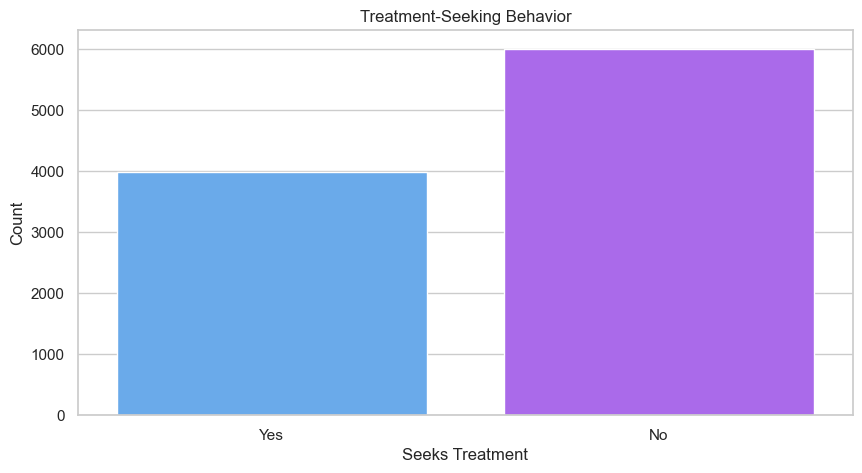

C:\Users\joe\AppData\Local\Temp\ipykernel_27408\1347251829.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='work_environment', palette='pastel')


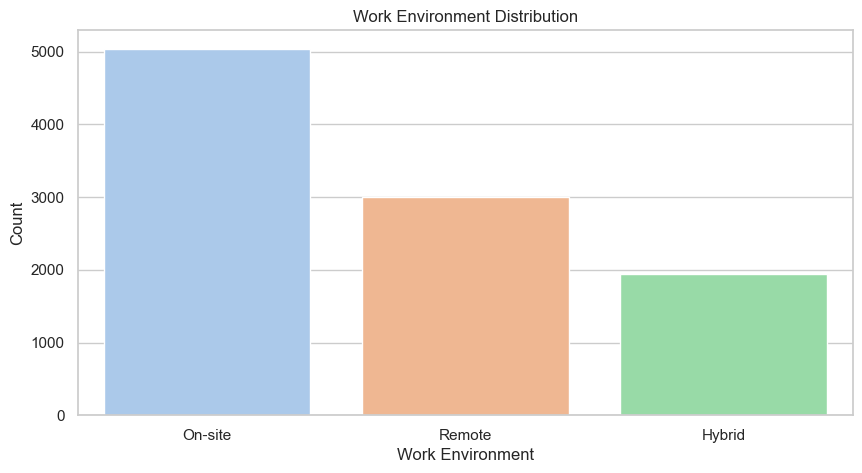

C:\Users\joe\AppData\Local\Temp\ipykernel_27408\1347251829.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='mental_health_risk', palette='coolwarm')


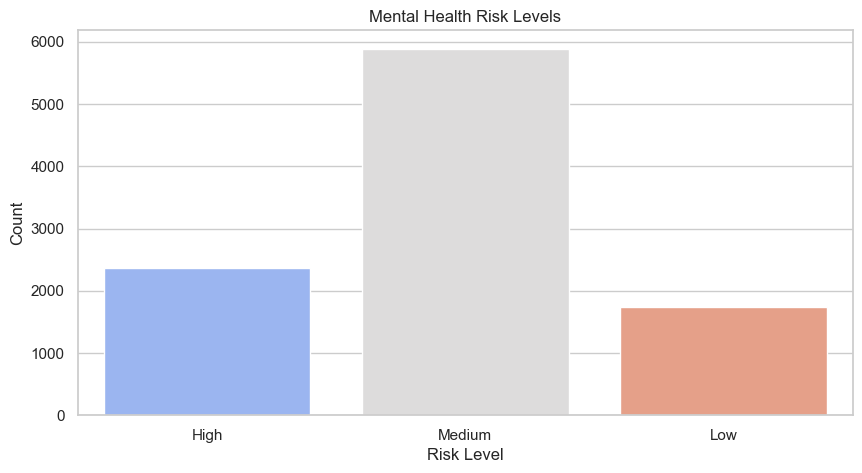

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='seeks_treatment', palette='cool')
plt.title('Treatment-Seeking Behavior')
plt.xlabel('Seeks Treatment')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='work_environment', palette='pastel')
plt.title('Work Environment Distribution')
plt.xlabel('Work Environment')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='mental_health_risk', palette='coolwarm')
plt.title('Mental Health Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.show()



## 5. Mental Health Risk vs Treatment Seeking
This analysis explores the relationship between mental health risk levels and treatment-seeking behavior. The visualizations help determine whether employees identified as high-risk are more likely to pursue professional help compared to those with lower risk levels. This insight can guide companies in identifying which groups may need more awareness or encouragement to seek support.

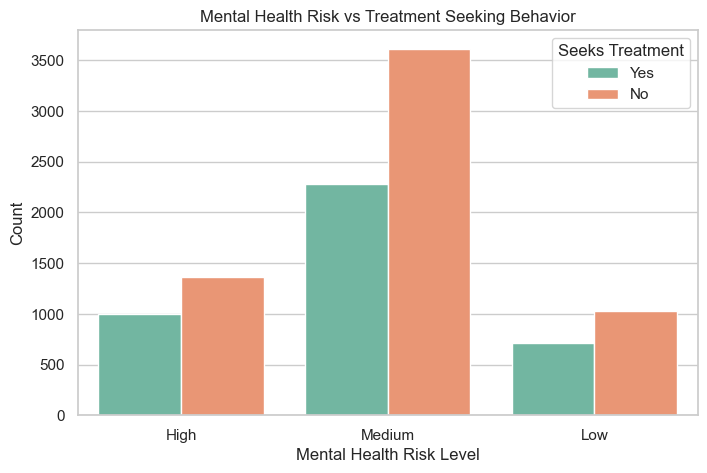

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='mental_health_risk', hue='seeks_treatment', palette='Set2')
plt.title('Mental Health Risk vs Treatment Seeking Behavior')
plt.xlabel('Mental Health Risk Level')
plt.ylabel('Count')
plt.legend(title='Seeks Treatment')
plt.show()


## 6. Correlation Between Numerical Features
In this section, we examine how key numerical features such as stress levels, sleep hours, depression scores, and productivity are related to one another. The correlation matrix helps identify which variables are strongly associated. For instance, higher stress levels might correlate negatively with productivity and sleep duration, while strong social support could correlate positively with better mental health outcomes.

c:\Users\joe\Desktop\ITCS3162_DataMining\itcs3162_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


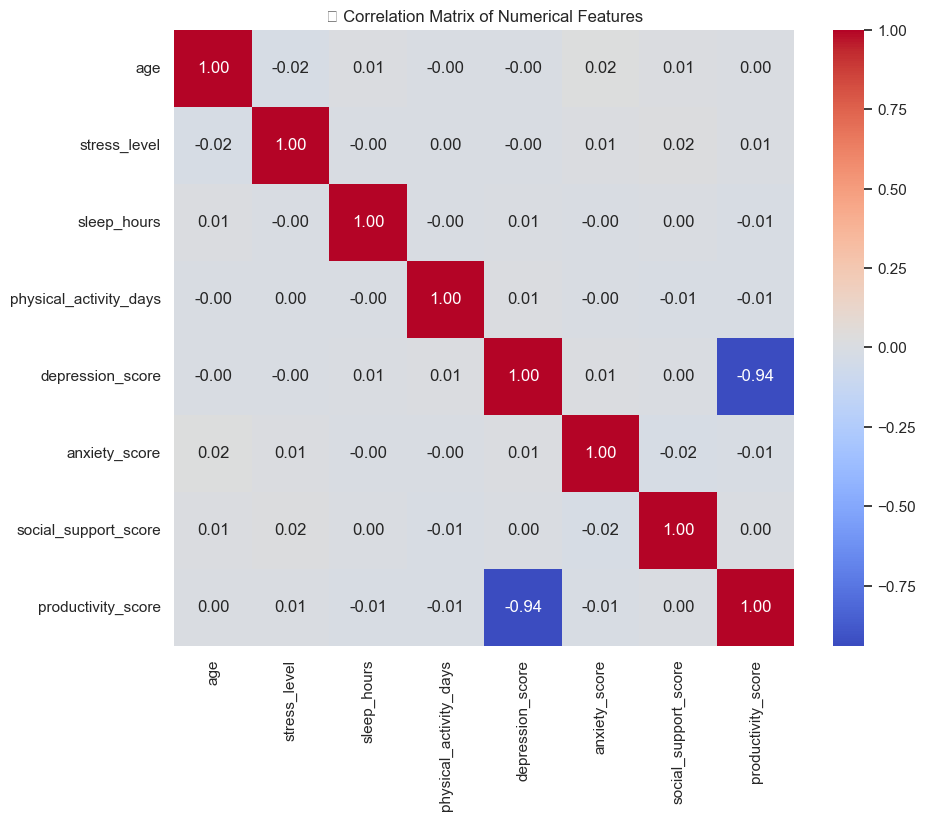

In [16]:
num_cols = ['age','stress_level','sleep_hours','physical_activity_days',
             'depression_score','anxiety_score','social_support_score','productivity_score']

plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('🔢 Correlation Matrix of Numerical Features')
plt.show()


## 7. Exploring Key Relationships
This step investigates how specific lifestyle factors influence mental health outcomes.

- The first visualization compares stress levels with productivity scores, revealing how increased stress may reduce performance.

- The second visualization examines sleep hours in relation to anxiety scores, showing how adequate rest contributes to lower anxiety levels.

Together, these visualizations highlight behavioral patterns that can inform healthier work-life balance strategies.

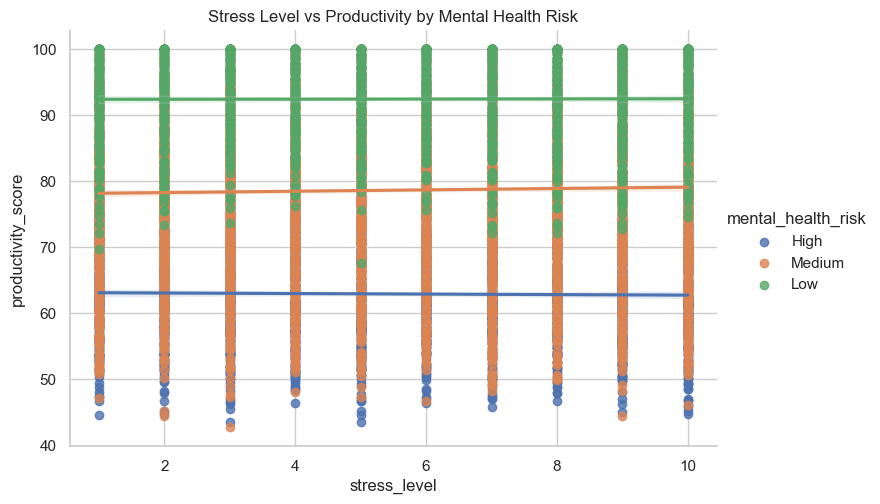

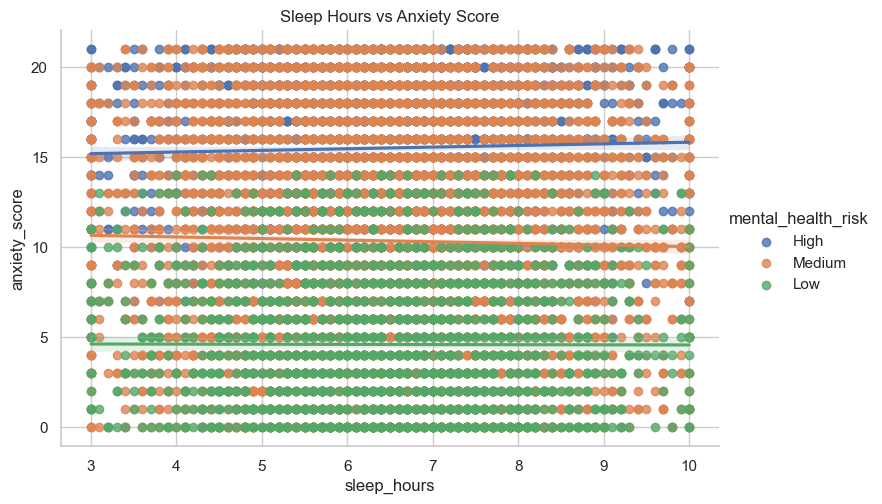

In [17]:
# Stress vs Productivity
sns.lmplot(data=df, x='stress_level', y='productivity_score', hue='mental_health_risk', height=5, aspect=1.5)
plt.title('Stress Level vs Productivity by Mental Health Risk')

# Sleep vs Anxiety
sns.lmplot(data=df, x='sleep_hours', y='anxiety_score', hue='mental_health_risk', height=5, aspect=1.5)
plt.title('Sleep Hours vs Anxiety Score')

plt.show()


## 8. Average Scores by Mental Health Risk
To gain deeper insight, we calculate the average values of key well-being indicators—such as stress, sleep, depression, anxiety, and productivity—for each mental health risk category.
This allows us to observe trends across groups and understand how risk levels differ in terms of daily habits and overall wellness. Visualizing these averages provides a clear picture of which areas may need the most attention for employee wellness programs.

In [18]:
avg_scores = df.groupby('mental_health_risk')[['stress_level','sleep_hours','depression_score','anxiety_score','productivity_score']].mean().round(2)
avg_scores


,stress_level,sleep_hours,depression_score,anxiety_score,productivity_score
mental_health_risk,,,,,
High,5.58,6.47,24.72,15.50,62.93
Low,5.53,6.44,4.68,4.59,92.42
Medium,5.58,6.48,14.21,10.34,78.64


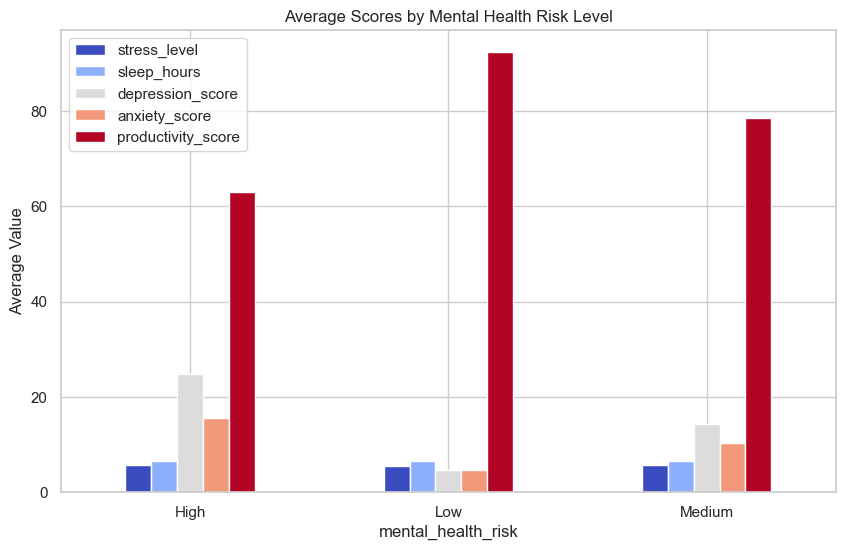

In [20]:
avg_scores.plot(kind='bar', figsize=(10,6), colormap='coolwarm')
plt.title('Average Scores by Mental Health Risk Level')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.show()


## 9. Insights & Interpretation
From the data exploration and visualizations, several meaningful patterns emerge:

- Employees classified as high-risk tend to report higher stress and anxiety levels, along with lower productivity.

- Increased sleep hours are generally associated with reduced anxiety and improved well-being.

- Employees working in remote or hybrid settings often report moderate to low mental health risk, possibly due to improved work-life balance and autonomy.

- Individuals with a family or personal history of mental illness are more likely to seek treatment, suggesting increased awareness of available support.

These findings emphasize the importance of flexible work arrangements, mental health benefits, and proactive wellness support in the tech industry.

## 10. Encoding Categorical Features (For Modeling)
Before applying machine learning models, categorical features must be converted into numerical form to make them compatible with algorithms such as Random Forest.
We use Label Encoding to transform features like gender, employment status, and mental health history into numerical codes. This step ensures that all variables can be analyzed consistently within the predictive framework.

In [21]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
encoder = LabelEncoder()

for col in ['gender','employment_status','work_environment','mental_health_history','seeks_treatment','mental_health_risk']:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

df_encoded.head()


,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk
0,56,1,0,1,1,1,6,6.2,3,28,17,54,59.7,0
1,46,0,2,1,0,1,10,9.0,4,30,11,85,54.9,0
2,32,0,0,1,1,0,7,7.7,2,24,7,62,61.3,2
3,60,2,1,1,0,0,4,4.5,4,6,0,95,97.0,1
4,25,0,1,1,1,1,3,5.4,0,24,12,70,69.0,0


## 11. Predicting Mental Health Risk (Random Forest)
A Random Forest Classifier is implemented to predict mental health risk levels based on all available features. This model uses multiple decision trees to make robust and accurate predictions.
By splitting the dataset into training and testing sets, we can evaluate how well the model generalizes to unseen data.
The accuracy score and classification report provide performance metrics that help assess the model’s effectiveness in predicting risk levels.


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Features and target
X = df_encoded.drop('mental_health_risk', axis=1)
y = df_encoded['mental_health_risk']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Results
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\n Classification Report:\n", classification_report(y_test, y_pred))


✅ Accuracy: 0.979

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.98       706
           1       0.98      0.96      0.97       521
           2       0.97      0.99      0.98      1773

    accuracy                           0.98      3000
   macro avg       0.98      0.97      0.98      3000
weighted avg       0.98      0.98      0.98      3000



## 12. Summary & Future Work
### Key Takeaways:
- Stress, sleep, and productivity are strong indicators of overall mental health risk.

- Supportive work environments, particularly hybrid or remote setups, tend to promote better mental well-being.

- Machine learning models, such as Random Forest, can predict mental health risk with reasonable accuracy even with limited data
### Future Steps:
To further improve this analysis, future work should:

- Incorporate a larger and more diverse dataset for stronger generalization.

- Experiment with additional algorithms such as logistic regression or neural networks for deeper insights.

- Conduct time-based studies to monitor changes in mental health patterns over time and evaluate the long-term effects of workplace interventions.
---

**Overall Reflection:**  
This project demonstrates the potential of data-driven approaches to understanding mental health in the workplace. Through a combination of visualization, clustering, and predictive modeling, we gain valuable insights into the factors influencing employee well-being.
By identifying distinct employee clusters and understanding their needs, organizations can design more targeted mental health initiatives, ultimately fostering healthier, more supportive, and more productive work environments.